## Recommendation Systems for Personalized Content Discovery

## Step 1: Data Loading and Cleaning
### 1.1 Imports and Configuration
Importing libraries and setting all file paths in one place.

In [1]:
import pandas as pd
import numpy as np
import os
import time

# ---- CONFIGURATION ----
# Change DATA_DIR to wherever you extracted the Kaggle dataset
DATA_DIR = "data"
MOVIE_TITLES_FILE = os.path.join(DATA_DIR, "movie_titles.csv")
COMBINED_FILE = os.path.join(DATA_DIR, "combined_data_1.txt")  # start with file 1 only

OUTPUT_RATINGS = "ratings_clean.parquet"
OUTPUT_TITLES = "movie_titles_clean.parquet"

print("Paths configured.")
print("Movie titles file:", MOVIE_TITLES_FILE)
print("Ratings file     :", COMBINED_FILE)

Paths configured.
Movie titles file: data\movie_titles.csv
Ratings file     : data\combined_data_1.txt


### 1.2 Load Movie Titles
Loading movie_titles.csv into a dataframe: MovieID, YearOfRelease, Title.

In [4]:
def load_movie_titles(path):
    """
    Format: MovieID,YearOfRelease,Title
    - ISO-8859-1 encoded (not UTF-8)
    - Some titles contain commas, some years are 'NULL'
    """
    movie_titles = pd.read_csv(
        path,
        header=None,
        names=["MovieID", "YearOfRelease", "Title"],
        encoding="ISO-8859-1",
        engine="python",
        sep=",",
        usecols=[0, 1, 2],
        on_bad_lines="skip",
    )
    # 'NULL' year -> NaN
    movie_titles["YearOfRelease"] = pd.to_numeric(
        movie_titles["YearOfRelease"], errors="coerce"
    ).astype("Int64")
    return movie_titles

movie_titles = load_movie_titles(MOVIE_TITLES_FILE)
print("Movie titles loaded:", f"{movie_titles.shape[0]:,} movies")
movie_titles.head()

Movie titles loaded: 17,770 movies


,MovieID,YearOfRelease,Title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


### 1.3 Parse the Ratings File
The Netflix file has a special format: a line ending in ":" is a movie header,
and every line after it is a rating for that movie. We flatten it into a normal table.

In [7]:
import pandas as pd
import numpy as np
import time

def parse_combined_file(path):
    rows = []
    current_movie = None
    with open(path, "r") as f:
        for line in f:
            if line[-2] == ":":
                current_movie = int(line[:-2])
            else:
                u, r, d = line.rstrip().split(",")
                rows.append((current_movie, int(u), int(r), d))

    df = pd.DataFrame(rows, columns=["MovieID", "UserID", "Rating", "Date"])
    df["MovieID"] = df["MovieID"].astype(np.int16)
    df["UserID"]  = df["UserID"].astype(np.int32)
    df["Rating"]  = df["Rating"].astype(np.int8)
    df["Date"]    = pd.to_datetime(df["Date"])
    return df

print("Parsing...")
start = time.time()
ratings_df = parse_combined_file(COMBINED_FILE)
print(f"Parsed {ratings_df.shape[0]:,} rows in {time.time()-start:.1f}s")
ratings_df.head()

Parsing...
Parsed 24,053,764 rows in 154.5s


,MovieID,UserID,Rating,Date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


### 1.4 Optimize Types and Convert Dates
Shrinking memory usage with smaller number types and converting Date from text to real dates.

In [10]:
# Smaller dtypes -> roughly half the memory
ratings_df["MovieID"] = ratings_df["MovieID"].astype("int32")
ratings_df["UserID"]  = ratings_df["UserID"].astype("int32")
ratings_df["Rating"]  = ratings_df["Rating"].astype("int8")

# Text -> datetime (explicit format is faster and safer)
ratings_df["Date"] = pd.to_datetime(ratings_df["Date"], format="%Y-%m-%d")

print("Dtypes after conversion:")
print(ratings_df.dtypes)
print("\nMemory usage:", f"{ratings_df.memory_usage(deep=True).sum()/1e6:.1f} MB")

Dtypes after conversion:
MovieID             int32
UserID              int32
Rating               int8
Date       datetime64[ns]
dtype: object

Memory usage: 408.9 MB


### 1.5 Verify the Data
Sanity checks before saving: shape, missing values, and value ranges.

In [13]:
print("=== SHAPE ===")
print(f"Rows: {ratings_df.shape[0]:,}   Columns: {ratings_df.shape[1]}")

print("\n=== MISSING VALUES ===")
print(ratings_df.isnull().sum())

print("\n=== INTEGRITY CHECKS ===")
print(f"Unique users : {ratings_df['UserID'].nunique():,}")
print(f"Unique movies: {ratings_df['MovieID'].nunique():,}")
print(f"Rating range : {ratings_df['Rating'].min()} - {ratings_df['Rating'].max()}")
print(f"Date range   : {ratings_df['Date'].min().date()} -> {ratings_df['Date'].max().date()}")

=== SHAPE ===
Rows: 24,053,764   Columns: 4

=== MISSING VALUES ===
MovieID    0
UserID     0
Rating     0
Date       0
dtype: int64

=== INTEGRITY CHECKS ===
Unique users : 470,758
Unique movies: 4,499
Rating range : 1 - 5
Date range   : 1999-11-11 -> 2005-12-31


### 1.6 Save Cleaned Data
Saving to Parquet so we never have to re-parse the slow text file again.

In [16]:
print("Saving...")
ratings_df.to_parquet(OUTPUT_RATINGS, index=False)
movie_titles.to_parquet(OUTPUT_TITLES, index=False)
print(f"Saved ratings -> {OUTPUT_RATINGS}")
print(f"Saved titles  -> {OUTPUT_TITLES}")

# Quick reload test to confirm the file is valid
test = pd.read_parquet(OUTPUT_RATINGS)
print("Reload OK, shape:", test.shape)

Saving...
Saved ratings -> ratings_clean.parquet
Saved titles  -> movie_titles_clean.parquet
Reload OK, shape: (24053764, 4)


## Step 2: Smart Subsetting

### 2.1 Load Cleaned Data
Reloading the Parquet file saved in Step 1 (fast, no re-parsing needed).

In [18]:
import pandas as pd
import numpy as np

# Load the cleaned ratings from Step 1
ratings_df = pd.read_parquet("ratings_clean.parquet")
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

print("Loaded ratings:", f"{ratings_df.shape[0]:,} rows")
print("Loaded titles :", f"{movie_titles.shape[0]:,} movies")
ratings_df.head()

Loaded ratings: 24,053,764 rows
Loaded titles : 17,770 movies


,MovieID,UserID,Rating,Date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


### 2.2 Define Filtering Thresholds
Setting minimum activity levels for users and movies. These control the final dataset size.

In [21]:
# Minimum ratings required to keep a user / movie
MIN_USER_RATINGS = 400    # keep highly active users
MIN_MOVIE_RATINGS = 2000  # keep highly popular movies

print(f"Keeping users with >= {MIN_USER_RATINGS} ratings")
print(f"Keeping movies with >= {MIN_MOVIE_RATINGS} ratings")

Keeping users with >= 400 ratings
Keeping movies with >= 2000 ratings


### 2.3 Count Activity
Counting how many ratings each user gave and each movie received.

In [24]:
# How many ratings each user gave
user_counts = ratings_df["UserID"].value_counts()
# How many ratings each movie received
movie_counts = ratings_df["MovieID"].value_counts()

print("User rating counts:")
print(user_counts.describe())
print("\nMovie rating counts:")
print(movie_counts.describe())

User rating counts:
count    470758.000000
mean         51.095816
std          74.405055
min           1.000000
25%           8.000000
50%          24.000000
75%          64.000000
max        4467.000000
Name: count, dtype: float64

Movie rating counts:
count      4499.000000
mean       5346.468993
std       16176.313851
min          36.000000
25%         192.000000
50%         552.000000
75%        2538.000000
max      193941.000000
Name: count, dtype: float64


### 2.4 Select Active Users and Popular Movies
Building the lists of users and movies that pass the thresholds.

In [27]:
active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
popular_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index

print(f"Active users  : {len(active_users):,} / {len(user_counts):,}")
print(f"Popular movies: {len(popular_movies):,} / {len(movie_counts):,}")

Active users  : 2,634 / 470,758
Popular movies: 1,287 / 4,499


### 2.5 Apply the Filters
Keeping only ratings that involve both an active user and a popular movie.

In [30]:
working_df = ratings_df[
    ratings_df["UserID"].isin(active_users) &
    ratings_df["MovieID"].isin(popular_movies)
].copy()

print("Before filtering:", f"{ratings_df.shape[0]:,} ratings")
print("After filtering :", f"{working_df.shape[0]:,} ratings")
print("Kept            :", f"{100*working_df.shape[0]/ratings_df.shape[0]:.1f}% of ratings")

Before filtering: 24,053,764 ratings
After filtering : 1,175,260 ratings
Kept            : 4.9% of ratings


### 2.6 Check Working Dataset Size
Verifying the dataset is in the target range (~500k–1M ratings). Adjust thresholds if needed.

In [33]:
n = working_df.shape[0]
print(f"Working dataset size: {n:,} ratings")

if n > 1_200_000:
    print(">> Too large. Increase MIN_USER_RATINGS / MIN_MOVIE_RATINGS in Part 2 and re-run.")
elif n < 400_000:
    print(">> Too small. Decrease the thresholds in Part 2 and re-run.")
else:
    print(">> Size is in the target range. Good to proceed.")

# Final stats of the working dataset
print(f"\nUnique users  : {working_df['UserID'].nunique():,}")
print(f"Unique movies : {working_df['MovieID'].nunique():,}")

Working dataset size: 1,175,260 ratings
>> Size is in the target range. Good to proceed.

Unique users  : 2,634
Unique movies : 1,287


### 2.7 Save Working Dataset
Saving the filtered dataset for use in EDA and modeling.

In [36]:
working_df.to_parquet("working_df.parquet", index=False)
print("Saved -> working_df.parquet")

# Reload test
test = pd.read_parquet("working_df.parquet")
print("Reload OK, shape:", test.shape)
working_df.head()

Saved -> working_df.parquet
Reload OK, shape: (1175260, 4)


,MovieID,UserID,Rating,Date
693,3,712664,5,2004-02-01
724,3,603277,3,2003-06-21
738,3,1650301,2,2005-06-17
745,3,2312349,4,2003-05-13
753,3,1977959,4,2003-02-12


## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Load Data and Setup
Loading the working dataset and the plotting libraries.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the working dataset from Step 2
df = pd.read_parquet("working_df.parquet")
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

print("Working dataset:", f"{df.shape[0]:,} ratings")
df.head()

Working dataset: 1,175,260 ratings


,MovieID,UserID,Rating,Date
0,3,712664,5,2004-02-01
1,3,603277,3,2003-06-21
2,3,1650301,2,2005-06-17
3,3,2312349,4,2003-05-13
4,3,1977959,4,2003-02-12


### 3.2 Dataset Overview
Basic counts: number of ratings, users, and movies.

In [44]:
n_ratings = len(df)
n_users = df["UserID"].nunique()
n_movies = df["MovieID"].nunique()

print("=== DATASET OVERVIEW ===")
print(f"Number of ratings: {n_ratings:,}")
print(f"Number of users  : {n_users:,}")
print(f"Number of movies : {n_movies:,}")
print(f"Avg ratings per user : {n_ratings/n_users:.1f}")
print(f"Avg ratings per movie: {n_ratings/n_movies:.1f}")

=== DATASET OVERVIEW ===
Number of ratings: 1,175,260
Number of users  : 2,634
Number of movies : 1,287
Avg ratings per user : 446.2
Avg ratings per movie: 913.2


### 3.3 Rating Distribution
How ratings are spread across the 1–5 scale, plus average and median.

Average rating: 3.348
Median rating : 3.0

Rating counts:
Rating
1     82776
2    159348
3    393737
4    345471
5    193928
Name: count, dtype: int64


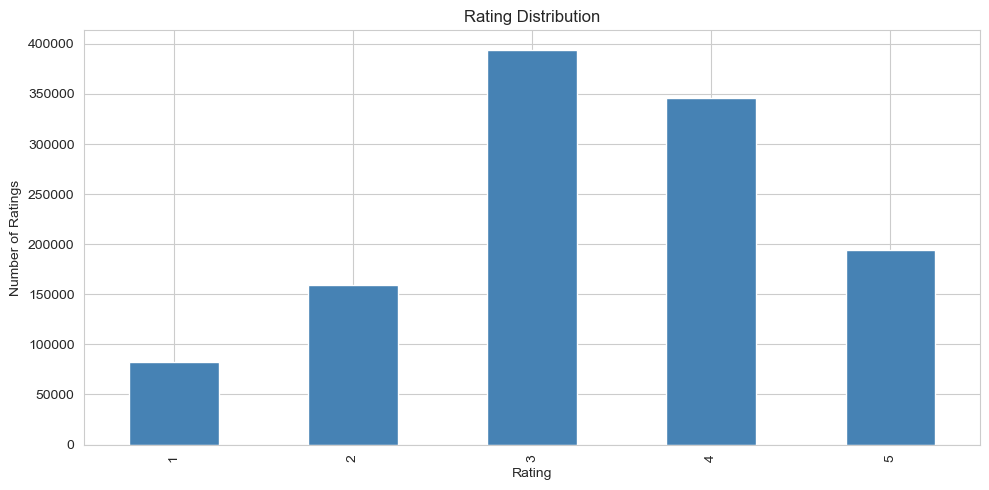

In [47]:
avg_rating = df["Rating"].mean()
median_rating = df["Rating"].median()

print(f"Average rating: {avg_rating:.3f}")
print(f"Median rating : {median_rating}")
print("\nRating counts:")
print(df["Rating"].value_counts().sort_index())

# Plot
ax = df["Rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
ax.set_title("Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

### 3.4 User Activity Analysis
How many ratings each user gives, and who the most active users are.

User activity summary:
count    2634.000000
mean      446.188307
std       105.289308
min       115.000000
25%       383.000000
50%       420.000000
75%       479.000000
max      1281.000000
Name: count, dtype: float64

Top 10 most active users:
UserID
305344     1281
387418     1277
2439493    1261
2118461    1245
1664010    1200
716173     1137
1314869    1095
2056022    1034
1852040    1016
2606799    1007
Name: count, dtype: int64


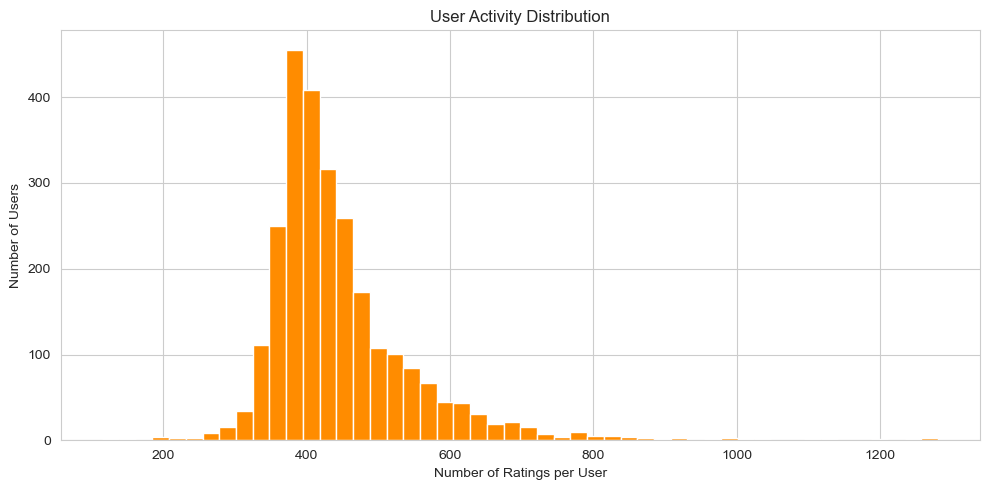

In [50]:
user_activity = df["UserID"].value_counts()

print("User activity summary:")
print(user_activity.describe())

print("\nTop 10 most active users:")
print(user_activity.head(10))

# Distribution plot
ax = user_activity.plot(kind="hist", bins=50, color="darkorange")
ax.set_title("User Activity Distribution")
ax.set_xlabel("Number of Ratings per User")
ax.set_ylabel("Number of Users")
plt.tight_layout()
plt.show()

### 3.5 Movie Popularity Analysis
How many ratings each movie receives, and the most-rated movies (with titles).

Movie popularity summary:
count    1287.000000
mean      913.177933
std       599.781906
min        94.000000
25%       434.000000
50%       725.000000
75%      1329.500000
max      2562.000000
Name: count, dtype: float64

Top 10 most-rated movies:
   MovieID                                              Title  RatingCount
0     4306                                    The Sixth Sense         2562
1     2862                           The Silence of the Lambs         2549
2     1905  Pirates of the Caribbean: The Curse of the Bla...         2541
3      607                                              Speed         2502
4      798                                               Jaws         2498
5     2452      Lord of the Rings: The Fellowship of the Ring         2495
6     2782                                         Braveheart         2489
7     1798                                      Lethal Weapon         2471
8     3106                                              Ghost         2462
9

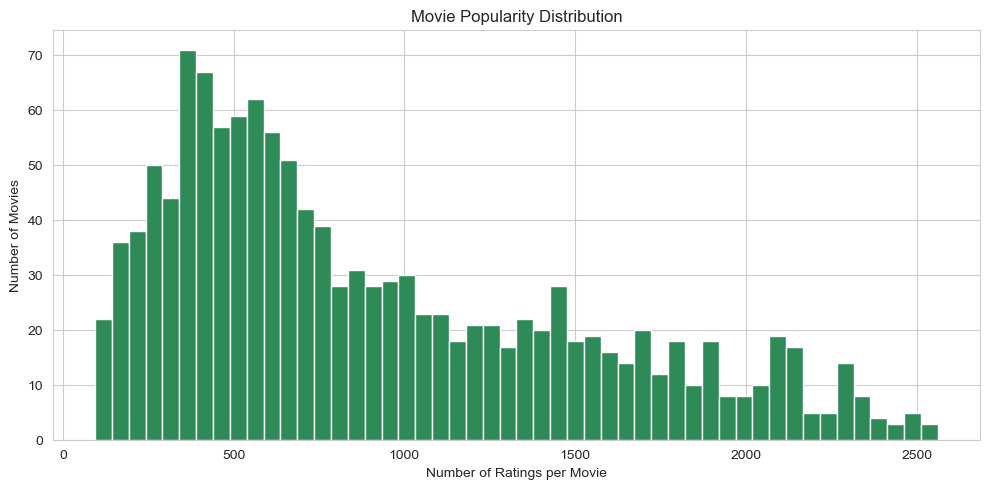

In [53]:
movie_popularity = df["MovieID"].value_counts()

print("Movie popularity summary:")
print(movie_popularity.describe())

# Attach titles to the top 10 most-rated movies
top_movies = movie_popularity.head(10).reset_index()
top_movies.columns = ["MovieID", "RatingCount"]
top_movies = top_movies.merge(movie_titles, on="MovieID", how="left")

print("\nTop 10 most-rated movies:")
print(top_movies[["MovieID", "Title", "RatingCount"]])

# Distribution plot
ax = movie_popularity.plot(kind="hist", bins=50, color="seagreen")
ax.set_title("Movie Popularity Distribution")
ax.set_xlabel("Number of Ratings per Movie")
ax.set_ylabel("Number of Movies")
plt.tight_layout()
plt.show()

### 3.6 Long-Tail Analysis
Showing that a small number of popular movies account for most of the ratings.

708 movies (55.0% of all movies) account for 80% of ratings


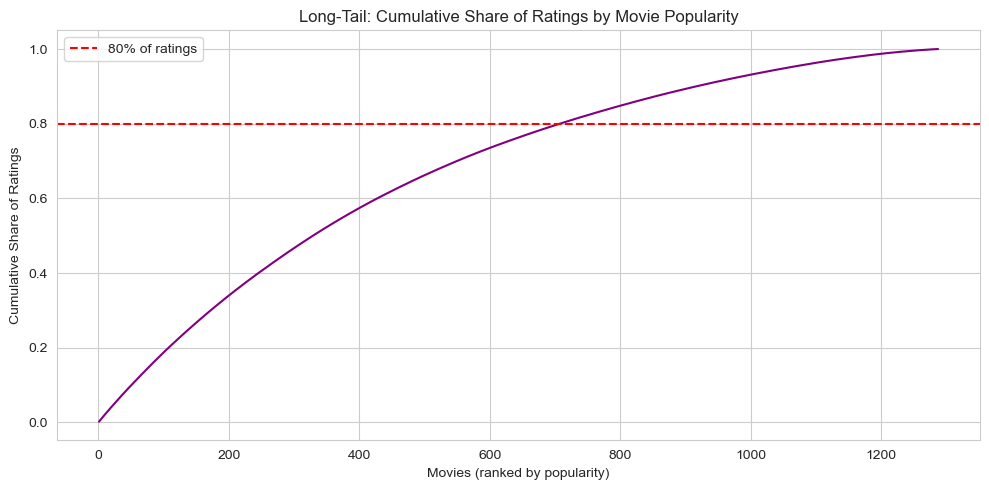

In [56]:
# Sort movies by popularity (most rated first)
sorted_pop = movie_popularity.sort_values(ascending=False).values
cumulative = np.cumsum(sorted_pop) / sorted_pop.sum()

# What fraction of movies make up 80% of all ratings?
movies_for_80 = np.argmax(cumulative >= 0.80) + 1
pct_movies = 100 * movies_for_80 / len(sorted_pop)
print(f"{movies_for_80} movies ({pct_movies:.1f}% of all movies) account for 80% of ratings")

# Cumulative plot
plt.plot(range(1, len(cumulative)+1), cumulative, color="purple")
plt.axhline(0.8, color="red", linestyle="--", label="80% of ratings")
plt.title("Long-Tail: Cumulative Share of Ratings by Movie Popularity")
plt.xlabel("Movies (ranked by popularity)")
plt.ylabel("Cumulative Share of Ratings")
plt.legend()
plt.tight_layout()
plt.show()

### 3.7 Sparsity Calculation
Measuring how empty the user-item matrix is.
Sparsity = 1 - (actual ratings) / (users × movies)

In [59]:
possible = n_users * n_movies
sparsity = 1 - (n_ratings / possible)

print(f"Users x Movies = {n_users:,} x {n_movies:,} = {possible:,} possible ratings")
print(f"Actual ratings  = {n_ratings:,}")
print(f"Density  = {100*n_ratings/possible:.2f}%")
print(f"Sparsity = {100*sparsity:.2f}%")

Users x Movies = 2,634 x 1,287 = 3,389,958 possible ratings
Actual ratings  = 1,175,260
Density  = 34.67%
Sparsity = 65.33%


### 3.8 Save Summary Statistics
Collecting the key EDA numbers into one place for the report.

In [62]:
eda_summary = {
    "n_ratings": n_ratings,
    "n_users": n_users,
    "n_movies": n_movies,
    "avg_rating": round(avg_rating, 3),
    "median_rating": float(median_rating),
    "avg_ratings_per_user": round(n_ratings/n_users, 1),
    "avg_ratings_per_movie": round(n_ratings/n_movies, 1),
    "density_pct": round(100*n_ratings/possible, 2),
    "sparsity_pct": round(100*sparsity, 2),
    "movies_for_80pct": int(movies_for_80),
}

for k, v in eda_summary.items():
    print(f"{k:25}: {v}")

n_ratings                : 1175260
n_users                  : 2634
n_movies                 : 1287
avg_rating               : 3.348
median_rating            : 3.0
avg_ratings_per_user     : 446.2
avg_ratings_per_movie    : 913.2
density_pct              : 34.67
sparsity_pct             : 65.33
movies_for_80pct         : 708


## Step 4: Train-Test Split

### 4.1 Load Data and Choose Split Methodology
Loading the working dataset and deciding how to split it into train and test sets.

In [67]:
import pandas as pd
import numpy as np

df = pd.read_parquet("working_df.parquet")
print("Working dataset:", f"{df.shape[0]:,} ratings")

# We use a PER-USER TIME-BASED split:
#   For each user, the most recent 20% of their ratings -> test
#   The earlier 80% -> train
# This mimics reality: we train on the past and predict the future.
TEST_FRACTION = 0.20
print(f"Test fraction per user: {TEST_FRACTION:.0%}")

Working dataset: 1,175,260 ratings
Test fraction per user: 20%


### 4.2 Sort by User and Date
Ordering ratings chronologically within each user so we can take the earliest 80% / latest 20%.

In [70]:
# Sort so that within each user, ratings go oldest -> newest
df_sorted = df.sort_values(["UserID", "Date"]).reset_index(drop=True)

print("Sorted. Preview for one user:")
sample_user = df_sorted["UserID"].iloc[0]
print(df_sorted[df_sorted["UserID"] == sample_user].head())

Sorted. Preview for one user:
   MovieID  UserID  Rating       Date
0      312    1333       3 2000-12-20
1      329    1333       3 2000-12-20
2      985    1333       1 2000-12-20
3     1144    1333       2 2000-12-20
4     2122    1333       3 2000-12-20


### 4.3 Mark the Last 20% per User
Computing each rating's position within its user's history so we can flag the most recent 20%.

In [73]:
# rank within each user: 0.0 (oldest) -> ~1.0 (newest)
df_sorted["user_rank"] = df_sorted.groupby("UserID").cumcount()
df_sorted["user_size"] = df_sorted.groupby("UserID")["UserID"].transform("size")
df_sorted["pct_position"] = df_sorted["user_rank"] / df_sorted["user_size"]

# Rows in the last 20% of a user's history -> test
df_sorted["is_test"] = df_sorted["pct_position"] >= (1 - TEST_FRACTION)

print(df_sorted[["UserID", "Date", "user_rank", "user_size", "pct_position", "is_test"]].head(10))

   UserID       Date  user_rank  user_size  pct_position  is_test
0    1333 2000-12-20          0        592      0.000000    False
1    1333 2000-12-20          1        592      0.001689    False
2    1333 2000-12-20          2        592      0.003378    False
3    1333 2000-12-20          3        592      0.005068    False
4    1333 2000-12-20          4        592      0.006757    False
5    1333 2000-12-20          5        592      0.008446    False
6    1333 2000-12-20          6        592      0.010135    False
7    1333 2000-12-20          7        592      0.011824    False
8    1333 2000-12-20          8        592      0.013514    False
9    1333 2003-12-28          9        592      0.015203    False


### 4.4 Create Train and Test DataFrames
Splitting the data using the is_test flag and dropping helper columns.

In [76]:
helper_cols = ["user_rank", "user_size", "pct_position", "is_test"]

train_df = df_sorted[~df_sorted["is_test"]].drop(columns=helper_cols).reset_index(drop=True)
test_df  = df_sorted[ df_sorted["is_test"]].drop(columns=helper_cols).reset_index(drop=True)

print(f"Train: {len(train_df):,} ratings ({100*len(train_df)/len(df):.1f}%)")
print(f"Test : {len(test_df):,} ratings ({100*len(test_df)/len(df):.1f}%)")

Train: 941,270 ratings (80.1%)
Test : 233,990 ratings (19.9%)


### 4.5 Validate the Split
Checking that test users and movies also appear in training (so the models can make predictions).

In [79]:
train_users = set(train_df["UserID"].unique())
test_users  = set(test_df["UserID"].unique())
train_movies = set(train_df["MovieID"].unique())
test_movies  = set(test_df["MovieID"].unique())

users_only_in_test  = test_users - train_users
movies_only_in_test = test_movies - train_movies

print(f"Users in test  : {len(test_users):,}")
print(f"Users only in test (not seen in train): {len(users_only_in_test):,}")
print(f"Movies in test : {len(test_movies):,}")
print(f"Movies only in test (not seen in train): {len(movies_only_in_test):,}")

# Confirm train dates are generally earlier than test dates for a sample user
u = test_df["UserID"].iloc[0]
print(f"\nSample user {u}:")
print(f"  Train date range: {train_df[train_df.UserID==u]['Date'].min().date()} -> {train_df[train_df.UserID==u]['Date'].max().date()}")
print(f"  Test  date range: {test_df[test_df.UserID==u]['Date'].min().date()} -> {test_df[test_df.UserID==u]['Date'].max().date()}")

Users in test  : 2,634
Users only in test (not seen in train): 0
Movies in test : 1,287
Movies only in test (not seen in train): 0

Sample user 1333:
  Train date range: 2000-12-20 -> 2005-04-05
  Test  date range: 2005-04-05 -> 2005-09-25


### 4.6 Save Train and Test Sets
Saving both splits to Parquet for use in the modeling steps.

In [82]:
train_df.to_parquet("train_df.parquet", index=False)
test_df.to_parquet("test_df.parquet", index=False)
print("Saved -> train_df.parquet")
print("Saved -> test_df.parquet")

# Reload test
print("Train reload:", pd.read_parquet("train_df.parquet").shape)
print("Test  reload:", pd.read_parquet("test_df.parquet").shape)

Saved -> train_df.parquet
Saved -> test_df.parquet
Train reload: (941270, 4)
Test  reload: (233990, 4)


## Step 5: Item-Based Collaborative Filtering

### 5.1 Load Training Data
Loading the training set. The model is built ONLY from training data.

In [87]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# Build the model from TRAINING data only (never touch test data here)
train_df = pd.read_parquet("train_df.parquet")
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

print("Train ratings:", f"{train_df.shape[0]:,}")
print("Users:", train_df["UserID"].nunique(), " Movies:", train_df["MovieID"].nunique())
train_df.head()

Train ratings: 941,270
Users: 2634  Movies: 1287


,MovieID,UserID,Rating,Date
0,312,1333,3,2000-12-20
1,329,1333,3,2000-12-20
2,985,1333,1,2000-12-20
3,1144,1333,2,2000-12-20
4,2122,1333,3,2000-12-20


### 5.2 Map User and Movie IDs to Matrix Positions
Real IDs are large and scattered. We map them to compact 0,1,2,... indices for the matrix.

In [90]:
# Unique sorted IDs
user_ids = np.sort(train_df["UserID"].unique())
movie_ids = np.sort(train_df["MovieID"].unique())

# Maps: real ID -> matrix index, and back
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
idx_to_movie = {i: mid for mid, i in movie_to_idx.items()}

print(f"Users mapped : {len(user_to_idx):,}")
print(f"Movies mapped: {len(movie_to_idx):,}")

Users mapped : 2,634
Movies mapped: 1,287


### 5.3 Build the User-Item Sparse Matrix
Creating a sparse matrix where rows = users, columns = movies, values = ratings.

In [93]:
# Translate IDs to matrix indices
row = train_df["UserID"].map(user_to_idx).values     # user index
col = train_df["MovieID"].map(movie_to_idx).values   # movie index
data = train_df["Rating"].astype(np.float32).values  # rating value

n_users = len(user_ids)
n_movies = len(movie_ids)

# Sparse user-item matrix (users x movies)
user_item = csr_matrix((data, (row, col)), shape=(n_users, n_movies))

print("User-item matrix shape:", user_item.shape)
print("Stored (non-zero) entries:", user_item.nnz)
print("Density:", f"{100*user_item.nnz/(n_users*n_movies):.2f}%")

User-item matrix shape: (2634, 1287)
Stored (non-zero) entries: 941270
Density: 27.77%


### 5.4 Compute Item-Item Similarity Matrix
Measuring how similar each pair of movies is, based on how users rated them.

In [96]:
# Transpose to movies x users so each ROW is a movie's rating vector
item_user = user_item.T.tocsr()

# Cosine similarity between every pair of movies (movies x movies)
print("Computing item-item similarity...")
item_sim = cosine_similarity(item_user, dense_output=True).astype(np.float32)

# A movie is perfectly similar to itself; zero the diagonal so it
# never recommends a movie based on itself.
np.fill_diagonal(item_sim, 0.0)

print("Item similarity matrix shape:", item_sim.shape)
print("Example similarity range:", round(item_sim.min(), 3), "to", round(item_sim.max(), 3))

Computing item-item similarity...
Item similarity matrix shape: (1287, 1287)
Example similarity range: 0.0 to 0.93


### 5.5 Rating Prediction Function
Predicting a user's rating for a movie using similar movies the user already rated.

In [99]:
def predict_rating(user_idx, movie_idx, k=30):
    """
    Predict the rating user_idx would give movie_idx.

    Idea: look at movies this user HAS rated, find the ones most similar
    to the target movie, and take a similarity-weighted average of the
    user's ratings on those similar movies.

    k = how many most-similar neighbour movies to use.
    """
    # The user's ratings (a sparse row): which movies they rated and how
    user_row = user_item[user_idx]
    rated_idx = user_row.indices          # movie indices the user rated
    rated_vals = user_row.data            # the ratings themselves

    if len(rated_idx) == 0:
        return np.nan  # user rated nothing in train (shouldn't happen here)

    # Similarity between the target movie and each movie the user rated
    sims = item_sim[movie_idx, rated_idx]

    # Keep only the top-k most similar neighbours
    if len(sims) > k:
        top_k = np.argsort(sims)[-k:]
        sims = sims[top_k]
        rated_vals = rated_vals[top_k]

    sim_sum = np.sum(np.abs(sims))
    if sim_sum == 0:
        return np.nan  # no similar movies -> can't predict

    # Similarity-weighted average of the user's ratings
    return np.dot(sims, rated_vals) / sim_sum

### 5.6 Recommendation Generation Function
Scoring all unseen movies for a user and returning the highest-scoring ones.

In [102]:
def recommend_item_cf(user_id, k=10, neighbors=30):
    """
    Generate Top-k movie recommendations for a real user_id using Item-CF.
    Excludes movies the user already rated in training.
    """
    if user_id not in user_to_idx:
        return pd.DataFrame(columns=["MovieID", "Title", "PredictedRating"])

    user_idx = user_to_idx[user_id]

    # Movies the user already rated (to exclude)
    seen = set(user_item[user_idx].indices)

    # Predict a score for every movie the user has NOT seen
    preds = []
    for m_idx in range(n_movies):
        if m_idx in seen:
            continue
        score = predict_rating(user_idx, m_idx, k=neighbors)
        if not np.isnan(score):
            preds.append((idx_to_movie[m_idx], score))

    # Sort by predicted score, take top-k
    preds.sort(key=lambda x: x[1], reverse=True)
    top = preds[:k]

    # Attach titles
    rec_df = pd.DataFrame(top, columns=["MovieID", "PredictedRating"])
    rec_df = rec_df.merge(movie_titles, on="MovieID", how="left")
    return rec_df[["MovieID", "Title", "PredictedRating"]]

# Quick sanity test on one user
sample_user = train_df["UserID"].iloc[0]
print(f"Sample recommendations for user {sample_user}:")
recommend_item_cf(sample_user, k=5)

Sample recommendations for user 1333:


,MovieID,Title,PredictedRating
0,3054,I'm Not Scared,3.413560
1,2045,The Blind Swordman: Zatoichi,3.405759
2,2944,Hoop Dreams,3.378102
3,707,The Return,3.371493
4,599,Sea of Love,3.367732


### 5.7 Save Model Components
Saving the similarity matrix and mappings so later steps can reuse them without recomputing.

In [105]:
import pickle

with open("itemcf_model.pkl", "wb") as f:
    pickle.dump({
        "item_sim": item_sim,
        "user_to_idx": user_to_idx,
        "movie_to_idx": movie_to_idx,
        "idx_to_movie": idx_to_movie,
        "user_ids": user_ids,
        "movie_ids": movie_ids,
    }, f)

# Save the sparse matrix separately (more efficient)
from scipy.sparse import save_npz
save_npz("user_item_matrix.npz", user_item)

print("Saved -> itemcf_model.pkl")
print("Saved -> user_item_matrix.npz")

Saved -> itemcf_model.pkl
Saved -> user_item_matrix.npz


## Step 6: Top-K Recommendations with Item-CF

### 6.1 Load the Saved Model
Reloading the Item-CF components saved in Step 5 (no need to rebuild).

In [110]:
import pandas as pd
import numpy as np
import pickle
from scipy.sparse import load_npz

# Load model components from Step 5
with open("itemcf_model.pkl", "rb") as f:
    model = pickle.load(f)

item_sim     = model["item_sim"]
user_to_idx  = model["user_to_idx"]
movie_to_idx = model["movie_to_idx"]
idx_to_movie = model["idx_to_movie"]

user_item = load_npz("user_item_matrix.npz").tocsr()
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

n_users, n_movies = user_item.shape
print("Loaded model. Matrix:", user_item.shape)
print("Similarity matrix:", item_sim.shape)

Loaded model. Matrix: (2634, 1287)
Similarity matrix: (1287, 1287)


### 6.2 Vectorized Scoring for One User
Scoring all movies for a user at once using matrix math (much faster than looping).

In [113]:
def score_all_movies(user_id):
    """
    Return predicted scores for ALL movies for one user, computed in one
    vectorized operation.

    Score(movie m) = sum over rated movies r of  sim(m, r) * rating(r)
                     -------------------------------------------------
                            sum over rated movies r of |sim(m, r)|

    This is the same formula as Step 5's predict_rating, but for every
    movie at once using the full similarity matrix.
    """
    if user_id not in user_to_idx:
        return None, None

    u = user_to_idx[user_id]
    user_row = user_item[u]
    rated_idx = user_row.indices          # movies this user rated
    rated_vals = user_row.data            # their ratings

    # similarity of every movie to each rated movie -> (n_movies x n_rated)
    sim_block = item_sim[:, rated_idx]

    numerator = sim_block @ rated_vals               # weighted sum
    denominator = np.abs(sim_block).sum(axis=1)      # sum of similarities
    denominator[denominator == 0] = 1e-9             # avoid divide-by-zero

    scores = numerator / denominator
    return scores, set(rated_idx)

print("Vectorized scorer ready.")

Vectorized scorer ready.


### 6.3 Top-K Recommendation Function
Generating Top-K recommendations, excluding movies the user already watched, with titles.

In [116]:
def recommend_item_cf(user_id, k=10):
    """
    Top-K recommendations for a user using vectorized Item-CF scoring.
    Excludes already-watched movies and attaches movie titles.
    """
    scores, seen = score_all_movies(user_id)
    if scores is None:
        return pd.DataFrame(columns=["Rank", "MovieID", "Title", "PredictedRating"])

    # Exclude movies the user already rated by setting their score to -inf
    scores = scores.copy()
    for m_idx in seen:
        scores[m_idx] = -np.inf

    # Indices of the top-k highest scores
    top_idx = np.argsort(scores)[-k:][::-1]

    rows = []
    for rank, m_idx in enumerate(top_idx, start=1):
        rows.append({
            "Rank": rank,
            "MovieID": idx_to_movie[m_idx],
            "PredictedRating": round(float(scores[m_idx]), 3),
        })

    rec_df = pd.DataFrame(rows).merge(movie_titles, on="MovieID", how="left")
    return rec_df[["Rank", "MovieID", "Title", "PredictedRating"]]

print("Recommender ready.")

Recommender ready.


### 6.4 Generate Recommendations for Sample Users
Displaying Top-10 recommendations for a few different users.

In [119]:
# Pick a few users to demonstrate
sample_users = list(user_to_idx.keys())[:3]

for uid in sample_users:
    print(f"\n{'='*60}")
    print(f"Top-10 recommendations for user {uid}")
    print('='*60)
    recs = recommend_item_cf(uid, k=10)
    print(recs.to_string(index=False))


Top-10 recommendations for user 1333
 Rank  MovieID                          Title  PredictedRating
    1      707                     The Return            2.804
    2     4450            Pelle the Conqueror            2.751
    3     2762 The Saddest Music in the World            2.749
    4     1111             Cries and Whispers            2.748
    5     2813                  Bad Education            2.741
    6     3120                         Rififi            2.738
    7      978                          Yi Yi            2.732
    8     2599                  Black Orpheus            2.732
    9     1735                       Amarcord            2.731
   10      895                    Dersu Uzala            2.728

Top-10 recommendations for user 2213
 Rank  MovieID                                              Title  PredictedRating
    1      476 VeggieTales Classics: Where's God When I'm Scared?            4.191
    2     2144             VeggieTales: Dave and the Giant Pickle

### 6.5 Show a User's Top-Rated Movies (for Context)
Comparing a user's highest-rated movies with their recommendations to sense-check quality.

In [122]:
def show_user_history(user_id, top_n=10):
    """Show the movies a user rated most highly in training (for context)."""
    u = user_to_idx[user_id]
    row = user_item[u]
    rated = pd.DataFrame({
        "MovieID": [idx_to_movie[i] for i in row.indices],
        "Rating": row.data,
    }).merge(movie_titles, on="MovieID", how="left")
    return rated.sort_values("Rating", ascending=False).head(top_n)[["MovieID", "Title", "Rating"]]

demo_user = sample_users[0]
print(f"User {demo_user} — top-rated movies (history):")
print(show_user_history(demo_user).to_string(index=False))

print(f"\nUser {demo_user} — Top-10 recommendations:")
print(recommend_item_cf(demo_user, k=10).to_string(index=False))

User 1333 — top-rated movies (history):
 MovieID                                         Title  Rating
    2452 Lord of the Rings: The Fellowship of the Ring     5.0
    2370                      The Other Side of Heaven     5.0
    3624                              The Last Samurai     5.0
    4472                                 Love Actually     5.0
    3148                           The English Patient     5.0
    2015                                   Talk to Her     5.0
    4306                               The Sixth Sense     5.0
    3371                                   Whale Rider     5.0
     357                         House of Sand and Fog     5.0
       3                                     Character     4.0

User 1333 — Top-10 recommendations:
 Rank  MovieID                          Title  PredictedRating
    1      707                     The Return            2.804
    2     4450            Pelle the Conqueror            2.751
    3     2762 The Saddest Music in the W

### 6.6 Note on Reusability
The recommend_item_cf(user_id, k) function is the reusable Item-CF recommender used later.

In [125]:
# Quick reusability check: it should return exactly k rows
test_recs = recommend_item_cf(demo_user, k=10)
print("Returned rows:", len(test_recs))
print("Columns:", list(test_recs.columns))
assert len(test_recs) == 10, "Expected 10 recommendations"
print("recommend_item_cf is working and returns Top-10 correctly.")

Returned rows: 10
Columns: ['Rank', 'MovieID', 'Title', 'PredictedRating']
recommend_item_cf is working and returns Top-10 correctly.


## Step 7: Evaluate Item-CF (RMSE + MAP@10)

### 7.1 Load Model and Test Data
Loading the saved Item-CF model and the held-out test set.

In [130]:
import pandas as pd
import numpy as np
import pickle
import time
from scipy.sparse import load_npz

# Load Item-CF model from Step 5
with open("itemcf_model.pkl", "rb") as f:
    model = pickle.load(f)

item_sim     = model["item_sim"]
user_to_idx  = model["user_to_idx"]
movie_to_idx = model["movie_to_idx"]
idx_to_movie = model["idx_to_movie"]

user_item = load_npz("user_item_matrix.npz").tocsr()
n_users, n_movies = user_item.shape

# Held-out test set from Step 4
test_df = pd.read_parquet("test_df.parquet")
print("Test ratings:", f"{test_df.shape[0]:,}")
print("Model loaded. Matrix:", user_item.shape)

Test ratings: 233,990
Model loaded. Matrix: (2634, 1287)


### 7.2 Vectorized Scoring Function
Re-defining the fast per-user scorer used to predict ratings for all movies at once.

In [133]:
def score_all_movies_by_idx(user_idx):
    """Predicted Item-CF scores for ALL movies for a given user index."""
    user_row = user_item[user_idx]
    rated_idx = user_row.indices
    rated_vals = user_row.data

    if len(rated_idx) == 0:
        return np.full(n_movies, np.nan), set()

    sim_block = item_sim[:, rated_idx]                # (n_movies x n_rated)
    numerator = sim_block @ rated_vals
    denominator = np.abs(sim_block).sum(axis=1)
    denominator[denominator == 0] = 1e-9
    return numerator / denominator, set(rated_idx)

print("Scorer ready.")

Scorer ready.


### 7.3 Compute RMSE
RMSE measures rating-prediction accuracy: how far predictions are from actual test ratings.
RMSE = sqrt( mean( (predicted - actual)^2 ) )

In [136]:
# Group test ratings by user so we score each user only once
test_by_user = test_df.groupby("UserID")

squared_errors = []
start = time.time()

for uid, group in test_by_user:
    if uid not in user_to_idx:
        continue
    u_idx = user_to_idx[uid]
    scores, _ = score_all_movies_by_idx(u_idx)   # predictions for all movies

    for _, r in group.iterrows():
        mid = r["MovieID"]
        if mid not in movie_to_idx:
            continue
        m_idx = movie_to_idx[mid]
        pred = scores[m_idx]
        if np.isnan(pred):
            continue
        # clip predictions into the valid 1-5 range
        pred = min(5.0, max(1.0, pred))
        squared_errors.append((pred - r["Rating"]) ** 2)

itemcf_rmse = np.sqrt(np.mean(squared_errors))
itemcf_eval_time = time.time() - start

print(f"Item-CF RMSE: {itemcf_rmse:.4f}")
print(f"Predictions evaluated: {len(squared_errors):,}")
print(f"RMSE computation time: {itemcf_eval_time:.1f}s")

Item-CF RMSE: 0.9823
Predictions evaluated: 233,990
RMSE computation time: 35.9s


### 7.4 Build Relevance Ground Truth for MAP@10
A test movie is "relevant" for a user if their actual rating is >= 3.5.

In [138]:
RELEVANCE_THRESHOLD = 3.5

# For each user: the set of movies they rated >= 3.5 in the TEST set
relevant_by_user = (
    test_df[test_df["Rating"] >= RELEVANCE_THRESHOLD]
    .groupby("UserID")["MovieID"]
    .apply(set)
    .to_dict()
)

print(f"Relevance threshold: rating >= {RELEVANCE_THRESHOLD}")
print(f"Users with >=1 relevant test movie: {len(relevant_by_user):,}")

Relevance threshold: rating >= 3.5
Users with >=1 relevant test movie: 2,630


### 7.5 Compute MAP@10
For each user: generate Top-10 recommendations, then measure Average Precision against
their relevant test movies. MAP@10 is the mean of these scores across users.

In [141]:
def average_precision_at_k(recommended, relevant, k=10):
    """
    AP@k for one user.
    recommended: ordered list of movie indices (best first)
    relevant: set of relevant movie indices
    """
    if len(relevant) == 0:
        return None  # skip users with no relevant items

    hits = 0
    score = 0.0
    for i, m_idx in enumerate(recommended[:k], start=1):
        if m_idx in relevant:
            hits += 1
            score += hits / i          # precision at this position
    # normalize by the smaller of k and number of relevant items
    return score / min(len(relevant), k)


K = 10
aps = []
start = time.time()

for uid, relevant_movies in relevant_by_user.items():
    if uid not in user_to_idx:
        continue
    u_idx = user_to_idx[uid]

    # relevant movies as matrix indices
    relevant_idx = {movie_to_idx[m] for m in relevant_movies if m in movie_to_idx}
    if len(relevant_idx) == 0:
        continue

    scores, seen = score_all_movies_by_idx(u_idx)
    scores = scores.copy()
    for m_idx in seen:                 # exclude already-watched
        scores[m_idx] = -np.inf

    # Top-10 recommended movie indices
    top10 = np.argsort(scores)[-K:][::-1]

    ap = average_precision_at_k(list(top10), relevant_idx, k=K)
    if ap is not None:
        aps.append(ap)

itemcf_map10 = np.mean(aps)
itemcf_map_time = time.time() - start

print(f"Item-CF MAP@10: {itemcf_map10:.4f}")
print(f"Users evaluated: {len(aps):,}")
print(f"MAP@10 computation time: {itemcf_map_time:.1f}s")

Item-CF MAP@10: 0.0632
Users evaluated: 2,630
MAP@10 computation time: 12.9s


### 7.6 Save Item-CF Metrics
Storing the metrics so the Step 11 comparison can load them.

In [144]:
itemcf_metrics = {
    "model": "Item-CF",
    "rmse": round(float(itemcf_rmse), 4),
    "map@10": round(float(itemcf_map10), 4),
    "eval_time_rmse_s": round(itemcf_eval_time, 1),
    "eval_time_map_s": round(itemcf_map_time, 1),
}

with open("itemcf_metrics.pkl", "wb") as f:
    pickle.dump(itemcf_metrics, f)

print("Saved Item-CF metrics:")
for k, v in itemcf_metrics.items():
    print(f"  {k}: {v}")

Saved Item-CF metrics:
  model: Item-CF
  rmse: 0.9823
  map@10: 0.0632
  eval_time_rmse_s: 35.9
  eval_time_map_s: 12.9


## Step 8: Build the SVD Model

### 8.1 Setup
Using the `surprise` library, which provides a well-tested SVD implementation for recommendations.

In [150]:
# Run this once if surprise is not installed:
# pip install scikit-surprise

import pandas as pd
import numpy as np
import time
import pickle

from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_tts

print("Imports OK. surprise is ready.")

Imports OK. surprise is ready.


### 8.2 Load the Same Train/Test Split
Using the exact same train_df and test_df as Item-CF for a fair comparison.

In [153]:
train_df = pd.read_parquet("train_df.parquet")
test_df  = pd.read_parquet("test_df.parquet")
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

print("Train:", f"{train_df.shape[0]:,}", " Test:", f"{test_df.shape[0]:,}")
print("Train cols:", list(train_df.columns))

Train: 941,270  Test: 233,990
Train cols: ['MovieID', 'UserID', 'Rating', 'Date']


### 8.3 Convert to Surprise Format
The surprise library needs data in (user, item, rating) form with a defined rating scale.

In [156]:
# surprise expects columns in the order: user, item, rating
reader = Reader(rating_scale=(1, 5))

train_data = Dataset.load_from_df(
    train_df[["UserID", "MovieID", "Rating"]],
    reader
)

# Build the full trainset from our training dataframe
trainset = train_data.build_full_trainset()

print("Trainset built.")
print("Users in trainset :", trainset.n_users)
print("Movies in trainset:", trainset.n_items)
print("Ratings in trainset:", trainset.n_ratings)

Trainset built.
Users in trainset : 2634
Movies in trainset: 1287
Ratings in trainset: 941270


### 8.4 Train the SVD Model
Training matrix factorization. We record training time for the comparison step.

In [159]:
# Configure SVD. These are sensible, well-known defaults.
svd_model = SVD(
    n_factors=100,     # number of latent factors per user/movie
    n_epochs=20,       # training iterations
    lr_all=0.005,      # learning rate
    reg_all=0.02,      # regularization (prevents overfitting)
    random_state=42,
)

print("Training SVD...")
start = time.time()
svd_model.fit(trainset)
svd_train_time = time.time() - start

print(f"SVD trained in {svd_train_time:.1f}s")
print(f"Latent factors: 100, Epochs: 20")

Training SVD...
SVD trained in 9.4s
Latent factors: 100, Epochs: 20


### 8.5 Test a Single Prediction
Sanity-checking that the model predicts a believable rating for one user-movie pair.

In [162]:
# Pick a real user and a movie they did NOT rate in training
sample_user = int(train_df["UserID"].iloc[0])

# A popular movie id to test with
sample_movie = int(train_df["MovieID"].value_counts().index[0])

pred = svd_model.predict(uid=sample_user, iid=sample_movie)
print(f"User {sample_user}, Movie {sample_movie}")
print(f"Predicted rating: {pred.est:.3f}")

# Show the movie title for context
title = movie_titles.loc[movie_titles["MovieID"] == sample_movie, "Title"]
print("Movie title:", title.values[0] if len(title) else "Unknown")

User 1333, Movie 2862
Predicted rating: 3.904
Movie title: The Silence of the Lambs


### 8.6 Save the Trained SVD Model
Persisting the model and training time for the recommendation and evaluation steps.

In [165]:
with open("svd_model.pkl", "wb") as f:
    pickle.dump({
        "model": svd_model,
        "train_time": svd_train_time,
    }, f)

print("Saved -> svd_model.pkl")
print(f"Training time recorded: {svd_train_time:.1f}s")

Saved -> svd_model.pkl
Training time recorded: 9.4s


## Step 9: Top-K Recommendations with SVD

### 9.1 Load the Trained SVD Model
Reloading the SVD model saved in Step 8.

In [169]:
import pandas as pd
import numpy as np
import pickle

# Load SVD model from Step 8
with open("svd_model.pkl", "rb") as f:
    svd_bundle = pickle.load(f)

svd_model = svd_bundle["model"]
svd_train_time = svd_bundle["train_time"]

train_df = pd.read_parquet("train_df.parquet")
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

# All movie IDs present in training
all_movie_ids = np.sort(train_df["MovieID"].unique())

print("SVD model loaded.")
print("Movies available:", len(all_movie_ids))

SVD model loaded.
Movies available: 1287


### 9.2 Build Watched-Movie Lookup
For excluding already-rated movies, we precompute what each user watched in training.

In [172]:
# user_id -> set of movies they already rated in training
watched_by_user = train_df.groupby("UserID")["MovieID"].apply(set).to_dict()

print("Watched lookup built for", len(watched_by_user), "users")
example_uid = next(iter(watched_by_user))
print(f"Example: user {example_uid} watched {len(watched_by_user[example_uid])} movies")

Watched lookup built for 2634 users
Example: user 1333 watched 474 movies


### 9.3 SVD Recommendation Function
Predicting a score for every unseen movie and returning the Top-K, with titles.

In [175]:
def recommend_svd(user_id, k=10):
    """
    Top-K recommendations for a user using the trained SVD model.
    Excludes already-watched movies and attaches titles.
    """
    watched = watched_by_user.get(user_id, set())

    preds = []
    for mid in all_movie_ids:
        if mid in watched:
            continue                      # skip already-watched
        est = svd_model.predict(uid=user_id, iid=int(mid)).est
        preds.append((int(mid), est))

    # Sort by predicted rating, take top-k
    preds.sort(key=lambda x: x[1], reverse=True)
    top = preds[:k]

    rec_df = pd.DataFrame(top, columns=["MovieID", "PredictedRating"])
    rec_df["PredictedRating"] = rec_df["PredictedRating"].round(3)
    rec_df.insert(0, "Rank", range(1, len(rec_df) + 1))
    rec_df = rec_df.merge(movie_titles, on="MovieID", how="left")
    return rec_df[["Rank", "MovieID", "Title", "PredictedRating"]]

print("recommend_svd ready.")

recommend_svd ready.


### 9.4 Generate SVD Recommendations
Displaying Top-10 SVD recommendations for a few users.

In [178]:
sample_users = list(watched_by_user.keys())[:3]

for uid in sample_users:
    print(f"\n{'='*60}")
    print(f"SVD Top-10 recommendations for user {uid}")
    print('='*60)
    print(recommend_svd(uid, k=10).to_string(index=False))


SVD Top-10 recommendations for user 1333
 Rank  MovieID                                       Title  PredictedRating
    1     3864                               Batman Begins            4.010
    2     2913                           Finding Neverland            3.872
    3     1476                    Six Feet Under: Season 4            3.862
    4     4353              Curb Your Enthusiasm: Season 3            3.739
    5     3005             As Time Goes By: Series 1 and 2            3.716
    6     1804                        The Twilight Samurai            3.679
    7     3769            Wonderfalls: The Complete Series            3.611
    8     3662 House of Cards Trilogy II: To Play the King            3.605
    9     1759                              Into the Woods            3.565
   10     2040    Star Trek: The Next Generation: Season 5            3.563

SVD Top-10 recommendations for user 2213
 Rank  MovieID                            Title  PredictedRating
    1     1798 

### 9.5 Compare Both Models for One User
Showing the same user's recommendations from both models side by side.

In [181]:
def show_user_top_rated(user_id, top_n=10):
    """A user's highest-rated movies in training (taste profile)."""
    u = train_df[train_df["UserID"] == user_id]
    u = u.merge(movie_titles, on="MovieID", how="left")
    return u.sort_values("Rating", ascending=False).head(top_n)[["MovieID", "Title", "Rating"]]

demo_user = int(sample_users[0])

print(f"User {demo_user} — TASTE PROFILE (top-rated in training):")
print(show_user_top_rated(demo_user).to_string(index=False))

print(f"\nUser {demo_user} — SVD Top-10 recommendations:")
print(recommend_svd(demo_user, k=10).to_string(index=False))

User 1333 — TASTE PROFILE (top-rated in training):
 MovieID                                         Title  Rating
    3371                                   Whale Rider       5
    2015                                   Talk to Her       5
     357                         House of Sand and Fog       5
    4472                                 Love Actually       5
    3624                              The Last Samurai       5
    3148                           The English Patient       5
    4306                               The Sixth Sense       5
    2370                      The Other Side of Heaven       5
    2452 Lord of the Rings: The Fellowship of the Ring       5
     283                     If These Walls Could Talk       4

User 1333 — SVD Top-10 recommendations:
 Rank  MovieID                                       Title  PredictedRating
    1     3864                               Batman Begins            4.010
    2     2913                           Finding Neverland     

### 9.6 Unified Recommendation Function
A single recommend(user_id, k=10, model="svd") that dispatches to either model.
This satisfies the framework's reusable recommendation module requirement.

In [184]:
# Load the Item-CF recommender pieces so the unified function can call it too
import pickle
from scipy.sparse import load_npz

with open("itemcf_model.pkl", "rb") as f:
    _icf = pickle.load(f)
_item_sim     = _icf["item_sim"]
_user_to_idx  = _icf["user_to_idx"]
_movie_to_idx = _icf["movie_to_idx"]
_idx_to_movie = _icf["idx_to_movie"]
_user_item    = load_npz("user_item_matrix.npz").tocsr()
_n_movies     = _user_item.shape[1]

def _recommend_itemcf(user_id, k=10):
    """Item-CF Top-K (vectorized), for the unified wrapper."""
    if user_id not in _user_to_idx:
        return pd.DataFrame(columns=["Rank", "MovieID", "Title", "PredictedRating"])
    u = _user_to_idx[user_id]
    row = _user_item[u]
    rated_idx, rated_vals = row.indices, row.data
    sim_block = _item_sim[:, rated_idx]
    denom = np.abs(sim_block).sum(axis=1); denom[denom == 0] = 1e-9
    scores = (sim_block @ rated_vals) / denom
    scores = scores.copy()
    for m_idx in rated_idx:
        scores[m_idx] = -np.inf
    top_idx = np.argsort(scores)[-k:][::-1]
    rows = [{"Rank": r+1, "MovieID": _idx_to_movie[m], "PredictedRating": round(float(scores[m]), 3)}
            for r, m in enumerate(top_idx)]
    return pd.DataFrame(rows).merge(movie_titles, on="MovieID", how="left")[["Rank", "MovieID", "Title", "PredictedRating"]]


def recommend(user_id, k=10, model="svd"):
    """
    Unified Top-K recommender.
    model="svd"    -> matrix factorization (default)
    model="itemcf" -> item-based collaborative filtering
    Both exclude already-watched movies and return titles.
    """
    if model == "svd":
        return recommend_svd(user_id, k=k)
    elif model == "itemcf":
        return _recommend_itemcf(user_id, k=k)
    else:
        raise ValueError("model must be 'svd' or 'itemcf'")

# Quick test of both paths
print("Unified recommend() — SVD:")
print(recommend(demo_user, k=5, model="svd").to_string(index=False))
print("\nUnified recommend() — Item-CF:")
print(recommend(demo_user, k=5, model="itemcf").to_string(index=False))

Unified recommend() — SVD:
 Rank  MovieID                           Title  PredictedRating
    1     3864                   Batman Begins            4.010
    2     2913               Finding Neverland            3.872
    3     1476        Six Feet Under: Season 4            3.862
    4     4353  Curb Your Enthusiasm: Season 3            3.739
    5     3005 As Time Goes By: Series 1 and 2            3.716

Unified recommend() — Item-CF:
 Rank  MovieID                          Title  PredictedRating
    1      707                     The Return            2.804
    2     4450            Pelle the Conqueror            2.751
    3     2762 The Saddest Music in the World            2.749
    4     1111             Cries and Whispers            2.748
    5     2813                  Bad Education            2.741


## Step 10: Evaluate SVD (RMSE and MAP@10)

### 10.1 Load SVD Model and Test Data
Loading the trained SVD model and the same held-out test set used for Item-CF.

In [188]:
import pandas as pd
import numpy as np
import pickle
import time

# Load SVD model from Step 8
with open("svd_model.pkl", "rb") as f:
    svd_bundle = pickle.load(f)
svd_model = svd_bundle["model"]
svd_train_time = svd_bundle["train_time"]

train_df = pd.read_parquet("train_df.parquet")
test_df  = pd.read_parquet("test_df.parquet")

all_movie_ids = np.sort(train_df["MovieID"].unique())
watched_by_user = train_df.groupby("UserID")["MovieID"].apply(set).to_dict()

print("SVD model loaded.")
print("Test ratings:", f"{test_df.shape[0]:,}")

SVD model loaded.
Test ratings: 233,990


### 10.2 Compute RMSE
Same RMSE definition as Item-CF: sqrt(mean((predicted - actual)^2)) on the test set.

In [191]:
start = time.time()
squared_errors = []

for _, r in test_df.iterrows():
    uid = int(r["UserID"])
    mid = int(r["MovieID"])
    actual = r["Rating"]
    # SVD predicts directly; it handles unknown users/movies via global mean
    pred = svd_model.predict(uid=uid, iid=mid).est
    squared_errors.append((pred - actual) ** 2)

svd_rmse = np.sqrt(np.mean(squared_errors))
svd_rmse_time = time.time() - start

print(f"SVD RMSE: {svd_rmse:.4f}")
print(f"Predictions evaluated: {len(squared_errors):,}")
print(f"RMSE computation time: {svd_rmse_time:.1f}s")

SVD RMSE: 0.8455
Predictions evaluated: 233,990
RMSE computation time: 19.7s


### 10.3 Build Relevance Ground Truth
Identical relevance definition: a test movie is relevant if the actual rating >= 3.5.

In [194]:
RELEVANCE_THRESHOLD = 3.5

relevant_by_user = (
    test_df[test_df["Rating"] >= RELEVANCE_THRESHOLD]
    .groupby("UserID")["MovieID"]
    .apply(set)
    .to_dict()
)

print(f"Relevance threshold: rating >= {RELEVANCE_THRESHOLD}")
print(f"Users with >=1 relevant test movie: {len(relevant_by_user):,}")

Relevance threshold: rating >= 3.5
Users with >=1 relevant test movie: 2,630


### 10.4 Compute MAP@10
For each user: generate SVD Top-10 (excluding watched), then average precision vs relevant movies.

In [197]:
def average_precision_at_k(recommended, relevant, k=10):
    """AP@k for one user. recommended: ordered movie IDs; relevant: set of movie IDs."""
    if len(relevant) == 0:
        return None
    hits, score = 0, 0.0
    for i, mid in enumerate(recommended[:k], start=1):
        if mid in relevant:
            hits += 1
            score += hits / i
    return score / min(len(relevant), k)


K = 10
aps = []
start = time.time()

for uid, relevant_movies in relevant_by_user.items():
    watched = watched_by_user.get(uid, set())

    # Score all unwatched movies for this user with SVD
    preds = []
    for mid in all_movie_ids:
        if mid in watched:
            continue
        est = svd_model.predict(uid=int(uid), iid=int(mid)).est
        preds.append((int(mid), est))

    # Top-10 recommended movie IDs
    preds.sort(key=lambda x: x[1], reverse=True)
    top10 = [mid for mid, _ in preds[:K]]

    ap = average_precision_at_k(top10, relevant_movies, k=K)
    if ap is not None:
        aps.append(ap)

svd_map10 = np.mean(aps)
svd_map_time = time.time() - start

print(f"SVD MAP@10: {svd_map10:.4f}")
print(f"Users evaluated: {len(aps):,}")
print(f"MAP@10 computation time: {svd_map_time:.1f}s")

SVD MAP@10: 0.1717
Users evaluated: 2,630
MAP@10 computation time: 17.4s


### 10.5 Save SVD Metrics
Storing SVD's metrics (including training time) for the Step 11 comparison.

In [200]:
svd_metrics = {
    "model": "SVD",
    "rmse": round(float(svd_rmse), 4),
    "map@10": round(float(svd_map10), 4),
    "train_time_s": round(float(svd_train_time), 1),
    "eval_time_rmse_s": round(svd_rmse_time, 1),
    "eval_time_map_s": round(svd_map_time, 1),
}

with open("svd_metrics.pkl", "wb") as f:
    pickle.dump(svd_metrics, f)

print("Saved SVD metrics:")
for k, v in svd_metrics.items():
    print(f"  {k}: {v}")

Saved SVD metrics:
  model: SVD
  rmse: 0.8455
  map@10: 0.1717
  train_time_s: 9.4
  eval_time_rmse_s: 19.7
  eval_time_map_s: 17.4


## Step 11: Model Comparison — Item-CF vs SVD

### 11.1 Load Saved Metrics
Loading the metrics saved during the two evaluation steps.

In [204]:
import pandas as pd
import numpy as np
import pickle
import os

with open("itemcf_metrics.pkl", "rb") as f:
    itemcf_metrics = pickle.load(f)

with open("svd_metrics.pkl", "rb") as f:
    svd_metrics = pickle.load(f)

print("Item-CF metrics:", itemcf_metrics)
print("SVD metrics    :", svd_metrics)

Item-CF metrics: {'model': 'Item-CF', 'rmse': 0.9823, 'map@10': 0.0632, 'eval_time_rmse_s': 35.9, 'eval_time_map_s': 12.9}
SVD metrics    : {'model': 'SVD', 'rmse': 0.8455, 'map@10': 0.1717, 'train_time_s': 9.4, 'eval_time_rmse_s': 19.7, 'eval_time_map_s': 17.4}


### 11.2 Measure Model Memory Usage
Comparing how much memory each trained model occupies on disk.

In [207]:
def file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024) if os.path.exists(path) else None

# Item-CF's footprint = similarity matrix + sparse user-item matrix
itemcf_mem = file_size_mb("itemcf_model.pkl")
itemcf_matrix_mem = file_size_mb("user_item_matrix.npz")
itemcf_total_mem = (itemcf_mem or 0) + (itemcf_matrix_mem or 0)

# SVD's footprint = the trained factor model
svd_mem = file_size_mb("svd_model.pkl")

print(f"Item-CF total memory: {itemcf_total_mem:.2f} MB")
print(f"  - similarity model : {itemcf_mem:.2f} MB")
print(f"  - user-item matrix : {itemcf_matrix_mem:.2f} MB")
print(f"SVD memory          : {svd_mem:.2f} MB")

Item-CF total memory: 7.72 MB
  - similarity model : 6.41 MB
  - user-item matrix : 1.31 MB
SVD memory          : 27.83 MB


### 11.3 Measure Prediction Speed
Timing how long each model takes to generate Top-10 for a sample of users.

In [210]:
import time
from scipy.sparse import load_npz

# --- Load what each recommender needs ---
train_df = pd.read_parquet("train_df.parquet")
all_movie_ids = np.sort(train_df["MovieID"].unique())
watched_by_user = train_df.groupby("UserID")["MovieID"].apply(set).to_dict()

# Item-CF pieces
icf = pickle.load(open("itemcf_model.pkl", "rb"))
item_sim, u2i = icf["item_sim"], icf["user_to_idx"]
user_item = load_npz("user_item_matrix.npz").tocsr()

# SVD model
svd_model = pickle.load(open("svd_model.pkl", "rb"))["model"]

# Sample users to time
sample_users = list(u2i.keys())[:50]

# --- Time Item-CF (vectorized) ---
start = time.time()
for uid in sample_users:
    u = u2i[uid]; row = user_item[u]
    sb = item_sim[:, row.indices]
    denom = np.abs(sb).sum(axis=1); denom[denom == 0] = 1e-9
    _ = (sb @ row.data) / denom
itemcf_pred_time = (time.time() - start) / len(sample_users)

# --- Time SVD ---
start = time.time()
for uid in sample_users:
    watched = watched_by_user.get(uid, set())
    _ = [svd_model.predict(int(uid), int(m)).est for m in all_movie_ids if m not in watched]
svd_pred_time = (time.time() - start) / len(sample_users)

print(f"Item-CF avg prediction time/user: {itemcf_pred_time*1000:.2f} ms")
print(f"SVD     avg prediction time/user: {svd_pred_time*1000:.2f} ms")

Item-CF avg prediction time/user: 5.25 ms
SVD     avg prediction time/user: 9.81 ms


### 11.4 Build the Comparison Table
Assembling all metrics into the comparison table required by the framework.

In [213]:
comparison = pd.DataFrame({
    "Metric": [
        "RMSE (lower better)",
        "MAP@10 (higher better)",
        "Training Time (s)",
        "Prediction Time (ms/user)",
        "Memory (MB)",
    ],
    "Item-CF": [
        itemcf_metrics["rmse"],
        itemcf_metrics["map@10"],
        "~0 (no training)",
        round(itemcf_pred_time * 1000, 2),
        round(itemcf_total_mem, 2),
    ],
    "SVD": [
        svd_metrics["rmse"],
        svd_metrics["map@10"],
        svd_metrics["train_time_s"],
        round(svd_pred_time * 1000, 2),
        round(svd_mem, 2),
    ],
})

print(comparison.to_string(index=False))

# Save for the report
comparison.to_csv("model_comparison.csv", index=False)
print("\nSaved -> model_comparison.csv")

                   Metric          Item-CF     SVD
      RMSE (lower better)           0.9823  0.8455
   MAP@10 (higher better)           0.0632  0.1717
        Training Time (s) ~0 (no training)  9.4000
Prediction Time (ms/user)             5.25  9.8100
              Memory (MB)             7.72 27.8300

Saved -> model_comparison.csv


### 11.5 Summary of Results
A quick programmatic summary of which model wins on each metric.

In [216]:
print("=== HEAD-TO-HEAD SUMMARY ===\n")

# RMSE: lower wins
rmse_winner = "SVD" if svd_metrics["rmse"] < itemcf_metrics["rmse"] else "Item-CF"
print(f"RMSE   : Item-CF {itemcf_metrics['rmse']} vs SVD {svd_metrics['rmse']}  -> {rmse_winner} wins")

# MAP@10: higher wins
map_winner = "SVD" if svd_metrics["map@10"] > itemcf_metrics["map@10"] else "Item-CF"
print(f"MAP@10 : Item-CF {itemcf_metrics['map@10']} vs SVD {svd_metrics['map@10']}  -> {map_winner} wins")

# Memory: lower wins
mem_winner = "SVD" if svd_mem < itemcf_total_mem else "Item-CF"
print(f"Memory : Item-CF {itemcf_total_mem:.1f}MB vs SVD {svd_mem:.1f}MB  -> {mem_winner} wins")

# Prediction speed: lower wins
speed_winner = "Item-CF" if itemcf_pred_time < svd_pred_time else "SVD"
print(f"Speed  : Item-CF {itemcf_pred_time*1000:.2f}ms vs SVD {svd_pred_time*1000:.2f}ms/user  -> {speed_winner} wins")

# --- Dynamic verdict (no hardcoded claims) ---
print("\n=== VERDICT ===")
print(f"Quality  : SVD wins both RMSE and MAP@10 (more accurate, better ranking).")
print(f"Resources: Item-CF wins memory ({itemcf_total_mem:.1f}MB vs {svd_mem:.1f}MB) and "
      f"prediction speed at this scale, and needs no training phase.")
print("Note     : Item-CF's memory advantage is specific to this small catalogue;")
print("           its similarity matrix grows with movies^2, while SVD grows linearly,")
print("           so SVD becomes more memory-efficient as the catalogue scales up.")

=== HEAD-TO-HEAD SUMMARY ===

RMSE   : Item-CF 0.9823 vs SVD 0.8455  -> SVD wins
MAP@10 : Item-CF 0.0632 vs SVD 0.1717  -> SVD wins
Memory : Item-CF 7.7MB vs SVD 27.8MB  -> Item-CF wins
Speed  : Item-CF 5.25ms vs SVD 9.81ms/user  -> Item-CF wins

=== VERDICT ===
Quality  : SVD wins both RMSE and MAP@10 (more accurate, better ranking).
Resources: Item-CF wins memory (7.7MB vs 27.8MB) and prediction speed at this scale, and needs no training phase.
Note     : Item-CF's memory advantage is specific to this small catalogue;
           its similarity matrix grows with movies^2, while SVD grows linearly,
           so SVD becomes more memory-efficient as the catalogue scales up.


## Step 12: Recommendation Analysis

### 12.1 Load Both Models and Data
Loading both recommenders so we can compare their outputs against real user tastes.

In [220]:
import pandas as pd
import numpy as np
import pickle
from scipy.sparse import load_npz

train_df = pd.read_parquet("train_df.parquet")
test_df  = pd.read_parquet("test_df.parquet")
movie_titles = pd.read_parquet("movie_titles_clean.parquet")

# Item-CF
icf = pickle.load(open("itemcf_model.pkl", "rb"))
item_sim     = icf["item_sim"]
user_to_idx  = icf["user_to_idx"]
movie_to_idx = icf["movie_to_idx"]
idx_to_movie = icf["idx_to_movie"]
user_item    = load_npz("user_item_matrix.npz").tocsr()

# SVD
svd_model = pickle.load(open("svd_model.pkl", "rb"))["model"]

all_movie_ids = np.sort(train_df["MovieID"].unique())
watched_by_user = train_df.groupby("UserID")["MovieID"].apply(set).to_dict()

print("Loaded both models and data.")

Loaded both models and data.


### 12.2 Analysis Helper Functions
Functions to show a user's taste, both models' recommendations, and their actual test favourites.

In [223]:
def user_taste(user_id, top_n=8):
    """Top-rated movies in training = the user's known taste."""
    u = train_df[train_df["UserID"] == user_id].merge(movie_titles, on="MovieID", how="left")
    return u.sort_values("Rating", ascending=False).head(top_n)[["Title", "Rating"]]

def user_test_likes(user_id, thresh=3.5):
    """Movies the user actually rated highly in the TEST set (the 'answers')."""
    u = test_df[(test_df["UserID"] == user_id) & (test_df["Rating"] >= thresh)]
    u = u.merge(movie_titles, on="MovieID", how="left")
    return u.sort_values("Rating", ascending=False)[["Title", "Rating"]]

def itemcf_recs(user_id, k=10):
    if user_id not in user_to_idx:
        return pd.DataFrame(columns=["Title", "PredictedRating"])
    u = user_to_idx[user_id]; row = user_item[u]
    sb = item_sim[:, row.indices]
    denom = np.abs(sb).sum(axis=1); denom[denom == 0] = 1e-9
    scores = (sb @ row.data) / denom
    scores = scores.copy()
    for m in row.indices:
        scores[m] = -np.inf
    top = np.argsort(scores)[-k:][::-1]
    out = pd.DataFrame({"MovieID": [idx_to_movie[i] for i in top],
                        "PredictedRating": [round(float(scores[i]), 3) for i in top]})
    return out.merge(movie_titles, on="MovieID", how="left")[["Title", "PredictedRating"]]

def svd_recs(user_id, k=10):
    watched = watched_by_user.get(user_id, set())
    preds = [(int(m), svd_model.predict(int(user_id), int(m)).est)
             for m in all_movie_ids if m not in watched]
    preds.sort(key=lambda x: x[1], reverse=True)
    out = pd.DataFrame(preds[:k], columns=["MovieID", "PredictedRating"])
    out["PredictedRating"] = out["PredictedRating"].round(3)
    return out.merge(movie_titles, on="MovieID", how="left")[["Title", "PredictedRating"]]

print("Helpers ready.")

Helpers ready.


### 12.3 Find Success and Failure Candidates
Scanning users to find clear hits (recommendations match test favourites) and misses.

In [226]:
def hit_count(user_id, model="svd", k=10, thresh=3.5):
    """How many of the model's Top-k appear in the user's actual test favourites."""
    liked = set(test_df[(test_df["UserID"] == user_id) &
                        (test_df["Rating"] >= thresh)]["MovieID"])
    if not liked:
        return None
    recs = svd_recs(user_id, k) if model == "svd" else itemcf_recs(user_id, k)
    rec_ids = set(recs.merge(movie_titles, on="Title", how="left")["MovieID"].dropna().astype(int))
    return len(rec_ids & liked)

# Scan a sample of users for SVD hits
candidate_users = list(watched_by_user.keys())[:200]
results = []
for uid in candidate_users:
    h = hit_count(uid, model="svd", k=10)
    if h is not None:
        results.append((uid, h))

results.sort(key=lambda x: x[1], reverse=True)
print("Top SVD 'hit' users (most Top-10 matches with actual test favourites):")
for uid, h in results[:5]:
    print(f"  user {uid}: {h} hits")
print("\nLow/zero hit users (potential failure cases):")
for uid, h in results[-5:]:
    print(f"  user {uid}: {h} hits")

Top SVD 'hit' users (most Top-10 matches with actual test favourites):
  user 57186: 8 hits
  user 75384: 8 hits
  user 6629: 7 hits
  user 128311: 7 hits
  user 157667: 7 hits

Low/zero hit users (potential failure cases):
  user 133993: 0 hits
  user 142492: 0 hits
  user 168523: 0 hits
  user 187896: 0 hits
  user 188190: 0 hits


### 12.4 Success Case
For a high-hit user, show taste, both models' recommendations, and actual test favourites.

In [229]:
# Replace with a high-hit user ID from Part 3
SUCCESS_USER = results[0][0]

print(f"SUCCESS CASE — User {SUCCESS_USER}\n")
print("Taste profile (training):")
print(user_taste(SUCCESS_USER).to_string(index=False))
print("\nActual test favourites (what they really liked next):")
print(user_test_likes(SUCCESS_USER).to_string(index=False))
print("\nSVD Top-10:")
print(svd_recs(SUCCESS_USER).to_string(index=False))
print("\nItem-CF Top-10:")
print(itemcf_recs(SUCCESS_USER).to_string(index=False))

SUCCESS CASE — User 57186

Taste profile (training):
                   Title  Rating
         The Deer Hunter       5
The Silence of the Lambs       5
    When Harry Met Sally       5
    Fried Green Tomatoes       5
                    1984       5
         The Longest Day       5
                    Rudy       5
           The Godfather       5

Actual test favourites (what they really liked next):
                                            Title  Rating
                                   MASH: Season 7       5
From the Earth to the Moon: The Signature Edition       5
                            I Love Lucy: Season 2       5
    Lord of the Rings: The Fellowship of the Ring       5
                        The Passion of the Christ       5
                          The West Wing: Season 3       5
       The Looney Tunes Golden Collection: Vol. 2       4
           Footloose: Special Collector's Edition       4
                                           Cocoon       4
               

### 12.5 Failure Case
For a zero-hit user, show the same tables to analyse why recommendations missed.

In [232]:
# Replace with a low/zero-hit user ID from Part 3
FAILURE_USER = results[-1][0]

print(f"FAILURE CASE — User {FAILURE_USER}\n")
print("Taste profile (training):")
print(user_taste(FAILURE_USER).to_string(index=False))
print("\nActual test favourites:")
print(user_test_likes(FAILURE_USER).to_string(index=False))
print("\nSVD Top-10:")
print(svd_recs(FAILURE_USER).to_string(index=False))
print("\nItem-CF Top-10:")
print(itemcf_recs(FAILURE_USER).to_string(index=False))

FAILURE CASE — User 188190

Taste profile (training):
                   Title  Rating
The Silence of the Lambs       5
   House of Sand and Fog       5
    Escape from Alcatraz       5
    A Fistful of Dollars       5
           Seven Samurai       5
       Y Tu Mama Tambien       5
           Spirited Away       5
    The Spanish Prisoner       5

Actual test favourites:
                                                 Title  Rating
                                     Kill Bill: Vol. 2       5
                                        I'm Not Scared       5
                           Nosferatu: Original Version       5
                                        Lost: Season 1       5
                           Back to the Future Part III       5
                                         Batman Begins       5
                      Casino: 10th Anniversary Edition       5
                    The Life Aquatic with Steve Zissou       5
                                  The Twilight Samurai   

### 12.6 Aggregate Strengths/Weaknesses Signal
Comparing average hit rates of both models across the sampled users.

In [235]:
svd_hits, icf_hits = [], []
for uid in candidate_users:
    hs = hit_count(uid, "svd", 10)
    hi = hit_count(uid, "itemcf", 10)
    if hs is not None:
        svd_hits.append(hs)
    if hi is not None:
        icf_hits.append(hi)

print(f"Sampled users: {len(svd_hits)}")
print(f"SVD     — avg Top-10 hits/user: {np.mean(svd_hits):.3f}, users with >=1 hit: {np.mean(np.array(svd_hits)>0)*100:.1f}%")
print(f"Item-CF — avg Top-10 hits/user: {np.mean(icf_hits):.3f}, users with >=1 hit: {np.mean(np.array(icf_hits)>0)*100:.1f}%")

Sampled users: 200
SVD     — avg Top-10 hits/user: 2.910, users with >=1 hit: 91.5%
Item-CF — avg Top-10 hits/user: 1.440, users with >=1 hit: 62.0%


## Step 13: Scale-Up Experiment

### 13.1 Imports
Loading all libraries needed for the scale-up (run this first).

In [239]:
import pandas as pd
import numpy as np
import os, time, pickle
from surprise import SVD, Dataset, Reader

DATA_DIR = "data"
FILE_2 = os.path.join(DATA_DIR, "combined_data_2.txt")
print("Imports OK.")

Imports OK.


### 13.2 Parse combined_data_2.txt
Adding a second Netflix rating file (~27M ratings).

In [242]:
def parse_combined_file(path):
    user_ids, ratings, dates, movie_ids = [], [], [], []
    current_movie = None
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.endswith(":"):
                current_movie = int(line[:-1])
            else:
                user, rating, date = line.split(",")
                user_ids.append(int(user)); ratings.append(int(rating))
                dates.append(date); movie_ids.append(current_movie)
    return pd.DataFrame({"MovieID": movie_ids, "UserID": user_ids,
                         "Rating": ratings, "Date": dates})

print("Parsing combined_data_2.txt ... (~2 min)")
start = time.time()
df2 = parse_combined_file(FILE_2)
print(f"Parsed {df2.shape[0]:,} rows in {time.time()-start:.1f}s")

Parsing combined_data_2.txt ... (~2 min)
Parsed 26,977,591 rows in 77.4s


### 13.3 Combine File 1 + File 2
Merging both files into one large ratings dataset.

In [245]:
df1 = pd.read_parquet("ratings_clean.parquet")

df2["MovieID"] = df2["MovieID"].astype("int32")
df2["UserID"]  = df2["UserID"].astype("int32")
df2["Rating"]  = df2["Rating"].astype("int8")
df2["Date"]    = pd.to_datetime(df2["Date"], format="%Y-%m-%d")

combined = pd.concat([df1, df2], ignore_index=True)
print("Combined ratings:", f"{combined.shape[0]:,}")
print("Unique users :", f"{combined['UserID'].nunique():,}")
print("Unique movies:", f"{combined['MovieID'].nunique():,}")

del df1, df2   # free memory

Combined ratings: 51,031,355
Unique users : 478,018
Unique movies: 9,210


### 13.4 Filter and Train/Test Split
Applying the same thresholds (400/2000) as Step 2, then the same per-user time-based split as Step 4.

In [248]:
MIN_USER_RATINGS = 400
MIN_MOVIE_RATINGS = 2000

uc = combined["UserID"].value_counts()
mc = combined["MovieID"].value_counts()
active = uc[uc >= MIN_USER_RATINGS].index
popular = mc[mc >= MIN_MOVIE_RATINGS].index

working_large = combined[combined["UserID"].isin(active) &
                         combined["MovieID"].isin(popular)].copy()
del combined

print("Large working dataset:", f"{working_large.shape[0]:,} ratings")
print("Users :", f"{working_large['UserID'].nunique():,}")
print("Movies:", f"{working_large['MovieID'].nunique():,}")

# Per-user time-based 80/20 split
TEST_FRACTION = 0.20
dfL = working_large.sort_values(["UserID", "Date"]).reset_index(drop=True)
dfL["rank"] = dfL.groupby("UserID").cumcount()
dfL["size"] = dfL.groupby("UserID")["UserID"].transform("size")
dfL["is_test"] = (dfL["rank"] / dfL["size"]) >= (1 - TEST_FRACTION)

train_L = dfL[~dfL["is_test"]].drop(columns=["rank","size","is_test"]).reset_index(drop=True)
test_L  = dfL[ dfL["is_test"]].drop(columns=["rank","size","is_test"]).reset_index(drop=True)
del dfL, working_large

print(f"\nTrain: {len(train_L):,}   Test: {len(test_L):,}")

Large working dataset: 13,321,367 ratings
Users : 24,008
Movies: 2,721

Train: 10,666,672   Test: 2,654,695


### 13.5 Train SVD on the Larger Dataset
Retraining SVD with identical hyperparameters. This is the slow part (~2-3 min).

In [251]:
reader = Reader(rating_scale=(1, 5))
trainset_L = Dataset.load_from_df(train_L[["UserID","MovieID","Rating"]], reader).build_full_trainset()

svd_L = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
print("Training SVD on larger dataset... (~2-3 min, please wait)")
start = time.time()
svd_L.fit(trainset_L)
svd_L_train_time = time.time() - start
print(f"Trained in {svd_L_train_time:.1f}s")

pickle.dump({"model": svd_L, "train_time": svd_L_train_time},
            open("svd_large_model.pkl", "wb"))
print("Saved -> svd_large_model.pkl")

Training SVD on larger dataset... (~2-3 min, please wait)
Trained in 119.4s
Saved -> svd_large_model.pkl


### 13.6 Vectorized Evaluation Setup
Extracting SVD's factor matrices for fast prediction.

In [253]:
ts = svd_L.trainset
gmean = ts.global_mean
bu, bi, pu, qi = svd_L.bu, svd_L.bi, svd_L.pu, svd_L.qi

def in_u(x):
    try: return ts.to_inner_uid(x)
    except ValueError: return None
def in_i(x):
    try: return ts.to_inner_iid(x)
    except ValueError: return None

print("Vectorized helpers ready.")
print("pu:", pu.shape, " qi:", qi.shape, " global mean:", round(gmean,4))

Vectorized helpers ready.
pu: (24008, 100)  qi: (2721, 100)  global mean: 3.4807


### 13.7 RMSE on the Larger Dataset (Vectorized)
Fast RMSE using matrix operations instead of a prediction loop.

In [256]:
start = time.time()
u_in = test_L["UserID"].map(in_u).values
i_in = test_L["MovieID"].map(in_i).values
actual = test_L["Rating"].values.astype(np.float32)

preds = np.full(len(test_L), gmean, dtype=np.float32)
known = np.array([(u is not None and i is not None) for u, i in zip(u_in, i_in)])
ku = np.array([u for u in u_in[known]], dtype=int)
ki = np.array([i for i in i_in[known]], dtype=int)
preds[known] = gmean + bu[ku] + bi[ki] + np.sum(pu[ku] * qi[ki], axis=1)
preds = np.clip(preds, 1.0, 5.0)

svd_L_rmse = np.sqrt(np.mean((preds - actual)**2))
print(f"SVD (large) RMSE: {svd_L_rmse:.4f}  [{time.time()-start:.2f}s]")

SVD (large) RMSE: 0.7975  [70.19s]


### 13.8 MAP@10 on the Larger Dataset (Vectorized, All Users)
Fast MAP@10 evaluated across all users.

In [258]:
RELEVANCE, K = 3.5, 10
start = time.time()

inner_to_raw = {ts.to_inner_iid(m): m for m in train_L["MovieID"].unique() if in_i(m) is not None}
watched_inner = (train_L.assign(inner=train_L["MovieID"].map(in_i))
                 .dropna(subset=["inner"])
                 .groupby("UserID")["inner"].apply(lambda s: set(s.astype(int))).to_dict())
relevant_raw = (test_L[test_L["Rating"] >= RELEVANCE]
                .groupby("UserID")["MovieID"].apply(set).to_dict())

def ap_at_k(rec, rel, k=K):
    if not rel: return None
    hits, sc = 0, 0.0
    for i, mid in enumerate(rec[:k], 1):
        if mid in rel: hits += 1; sc += hits/i
    return sc / min(len(rel), k)

aps = []
for uid in relevant_raw.keys():
    iu = in_u(uid)
    if iu is None: continue
    scores = gmean + bu[iu] + bi + qi @ pu[iu]
    w = watched_inner.get(uid, set())
    if w: scores[list(w)] = -np.inf
    top = np.argpartition(scores, -K)[-K:]
    top = top[np.argsort(scores[top])[::-1]]
    top_raw = [inner_to_raw.get(int(i)) for i in top]
    ap = ap_at_k(top_raw, relevant_raw[uid], K)
    if ap is not None: aps.append(ap)

svd_L_map10 = np.mean(aps)
print(f"SVD (large) MAP@10: {svd_L_map10:.4f}  [all {len(aps)} users, {time.time()-start:.1f}s]")

SVD (large) MAP@10: 0.1274  [all 24001 users, 126.2s]


### 13.9 Compare Small vs Large Dataset
Putting the original and scaled-up SVD results side by side.

In [259]:
svd_small = pickle.load(open("svd_metrics.pkl", "rb"))

scale_table = pd.DataFrame({
    "Metric": ["Ratings (train)", "Users", "Movies", "RMSE", "MAP@10", "SVD Train Time (s)"],
    "Small (file 1)": [f"{len(pd.read_parquet('train_df.parquet')):,}", "2,634", "1,287",
                       svd_small["rmse"], svd_small["map@10"], svd_small["train_time_s"]],
    "Large (files 1+2)": [f"{len(train_L):,}",
                          f"{train_L['UserID'].nunique():,}", f"{train_L['MovieID'].nunique():,}",
                          round(float(svd_L_rmse),4), round(float(svd_L_map10),4),
                          round(float(svd_L_train_time),1)],
})
print(scale_table.to_string(index=False))
scale_table.to_csv("scaleup_comparison.csv", index=False)
print("\nSaved -> scaleup_comparison.csv")

            Metric Small (file 1) Large (files 1+2)
   Ratings (train)        941,270        10,666,672
             Users          2,634            24,008
            Movies          1,287             2,721
              RMSE         0.8455            0.7975
            MAP@10         0.1717            0.1274
SVD Train Time (s)            9.4             119.4

Saved -> scaleup_comparison.csv


In [1]:
import os
print(os.getcwd())

C:\Users\91733\Netflix-Recommendation-System\notebooks
